# Baseline Model: Logistic Regression cho Phân loại Khiếu nại (Complaint Detection)

Notebook này huấn luyện mô hình Logistic Regression kết hợp TF-IDF để phân loại các review là khiếu nại (1) hoặc không (0) từ dữ liệu Shopee.

**Dữ liệu:** `data/processed/shopee_mapped.csv`  
**Mô hình:** Logistic Regression + TF-IDF Vectorizer  
**Đánh giá:** Precision, Recall, F1-score, Confusion Matrix

## Bước 1: Import thư viện và kết nối đường dẫn

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Thiết lập encoding UTF-8 cho output tiếng Việt (bỏ qua trong Jupyter)
# Jupyter đã hỗ trợ UTF-8 mặc định

# Thêm đường dẫn root vào sys.path để import được hàm clean_vietnamese_text
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.utils.utils import clean_vietnamese_text

print("[OK] Tất cả thư viện đã import thành công!")
print(f"[INFO] Root directory: {ROOT_DIR}")

[OK] Tất cả thư viện đã import thành công!
[INFO] Root directory: c:\Users\Thang Vu\Documents\ie403-Ecom-MultiTask-Complaint-Detection


## Bước 2: Tải và Làm sạch dữ liệu

In [3]:
# Đọc file dữ liệu
data_path = '../data/processed/shopee_mapped.csv'
print(f"[INFO] Đang đọc file từ: {data_path}")
df = pd.read_csv(data_path, encoding='utf-8-sig')

print(f"[INFO] Số dòng ban đầu: {len(df)}")
print(f"[INFO] Các cột: {df.columns.tolist()}")

# Kiểm tra dữ liệu
print(f"\n[INFO] Thông tin dữ liệu:")
print(df.info())
print(f"\n[INFO] Phân phối nhãn:")
print(df['complaint_label'].value_counts())

[INFO] Đang đọc file từ: ../data/processed/shopee_mapped.csv
[INFO] Số dòng ban đầu: 7817
[INFO] Các cột: ['review', 'rating', 'complaint_label']

[INFO] Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 7817 entries, 0 to 7816
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   review           7817 non-null   str  
 1   rating           7817 non-null   int64
 2   complaint_label  7817 non-null   int64
dtypes: int64(2), str(1)
memory usage: 183.3 KB
None

[INFO] Phân phối nhãn:
complaint_label
1    4202
0    3615
Name: count, dtype: int64


In [4]:
# Xóa các dòng bị NaN ở cột 'review'
print(f"[INFO] Số NaN ở cột review trước: {df['review'].isna().sum()}")
df = df.dropna(subset=['review']).reset_index(drop=True)
print(f"[OK] Xóa xong NaN. Số dòng còn lại: {len(df)}")

# Áp dụng hàm clean_vietnamese_text để tạo cột mới 'cleaned_text'
print("\n[INFO] Đang làm sạch văn bản (Clean Vietnamese Text)...")
df['cleaned_text'] = df['review'].apply(lambda x: clean_vietnamese_text(str(x)))

print("[OK] Làm sạch xong!")
print(f"\n[INFO] Mẫu dữ liệu sau xử lý:")
print(df[['review', 'cleaned_text', 'complaint_label']].head(3))

[INFO] Số NaN ở cột review trước: 0
[OK] Xóa xong NaN. Số dòng còn lại: 7817

[INFO] Đang làm sạch văn bản (Clean Vietnamese Text)...
[OK] Làm sạch xong!

[INFO] Mẫu dữ liệu sau xử lý:
                                              review  \
0  Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...   
1  Chất lượng sản phẩm:ok Đúng với mô tả:đúng  Lầ...   
2  Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...   

                                        cleaned_text  complaint_label  
0  hương thơm nhẹ nhàng lợi ích phục hồi cấp ẩm m...                0  
1  chất lượng sản phẩm tốt đúng với mô tả đúng lầ...                0  
2  độ tuổi sử dụng em bes chất lượng sản phẩm tot...                0  


## Bước 3: Chia tập dữ liệu (Train/Test Split)

In [5]:
# Chia dữ liệu thành train (80%) và test (20%)
# Sử dụng stratify để giữ tỷ lệ class
print("[INFO] Chia tập dữ liệu: 80% train, 20% test")

X = df['cleaned_text']
y = df['complaint_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"[OK] Chia xong!")
print(f"[INFO] Kích thước train set: {len(X_train)} mẫu")
print(f"[INFO] Kích thước test set: {len(X_test)} mẫu")
print(f"\n[INFO] Phân phối nhãn trong train set:")
print(pd.Series(y_train).value_counts())
print(f"\n[INFO] Phân phối nhãn trong test set:")
print(pd.Series(y_test).value_counts())

[INFO] Chia tập dữ liệu: 80% train, 20% test
[OK] Chia xong!
[INFO] Kích thước train set: 6253 mẫu
[INFO] Kích thước test set: 1564 mẫu

[INFO] Phân phối nhãn trong train set:
complaint_label
1    3361
0    2892
Name: count, dtype: int64

[INFO] Phân phối nhãn trong test set:
complaint_label
1    841
0    723
Name: count, dtype: int64


## Bước 4: Trích xuất đặc trưng (Feature Extraction với TF-IDF)

In [6]:
# Khởi tạo TfidfVectorizer với unigram và bigram
print("[INFO] Khởi tạo TfidfVectorizer...")
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),      # Sử dụng unigram (1-gram) và bigram (2-gram)
    max_features=10000,      # Giới hạn 10000 features
    lowercase=True,
    min_df=2,                # Loại bỏ các từ xuất hiện < 2 lần
    max_df=0.8,              # Loại bỏ các từ xuất hiện trong > 80% tài liệu
    strip_accents='unicode'
)

# Fit trên tập train và transform
print("[INFO] Fit và transform tập train...")
X_train_tfidf = vectorizer.fit_transform(X_train)
print(f"[OK] Train TF-IDF shape: {X_train_tfidf.shape}")

# Transform tập test
print("[INFO] Transform tập test...")
X_test_tfidf = vectorizer.transform(X_test)
print(f"[OK] Test TF-IDF shape: {X_test_tfidf.shape}")

print(f"\n[INFO] Số lượng feature sau TF-IDF: {len(vectorizer.get_feature_names_out())}")

[INFO] Khởi tạo TfidfVectorizer...
[INFO] Fit và transform tập train...
[OK] Train TF-IDF shape: (6253, 10000)
[INFO] Transform tập test...
[OK] Test TF-IDF shape: (1564, 10000)

[INFO] Số lượng feature sau TF-IDF: 10000


## Bước 5: Huấn luyện mô hình Logistic Regression

In [7]:
# Khởi tạo mô hình Logistic Regression
print("[INFO] Khởi tạo mô hình Logistic Regression...")
model = LogisticRegression(
    class_weight='balanced',  # Xử lý mất cân bằng dữ liệu
    max_iter=1000,            # Số lần lặp tối đa
    random_state=42,
    solver='lbfgs',           # Solver tối ưu
    verbose=0
)

# Huấn luyện mô hình
print("[INFO] Đang huấn luyện mô hình trên tập train...")
model.fit(X_train_tfidf, y_train)

print("[OK] Huấn luyện xong!")
print(f"[INFO] Số lớp: {len(model.classes_)}")
print(f"[INFO] Các lớp: {model.classes_}")

[INFO] Khởi tạo mô hình Logistic Regression...
[INFO] Đang huấn luyện mô hình trên tập train...
[OK] Huấn luyện xong!
[INFO] Số lớp: 2
[INFO] Các lớp: [0 1]


## Bước 6: Đánh giá mô hình và Vẽ biểu đồ (Evaluation & Visualization)

In [8]:
# Dự đoán trên tập test
print("[INFO] Dự đoán trên tập test...")
y_pred = model.predict(X_test_tfidf)

# Tính độ chính xác (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"[INFO] Accuracy trên tập test: {accuracy:.4f}")

# In ra classification report (Precision, Recall, F1-score)
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Precision, Recall, F1-score)")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['Bình thường (0)', 'Khiếu nại (1)']))
print("="*70)

[INFO] Dự đoán trên tập test...
[INFO] Accuracy trên tập test: 0.9393

CLASSIFICATION REPORT (Precision, Recall, F1-score)
                 precision    recall  f1-score   support

Bình thường (0)       0.93      0.94      0.93       723
  Khiếu nại (1)       0.95      0.94      0.94       841

       accuracy                           0.94      1564
      macro avg       0.94      0.94      0.94      1564
   weighted avg       0.94      0.94      0.94      1564



[INFO] Vẽ biểu đồ Confusion Matrix...


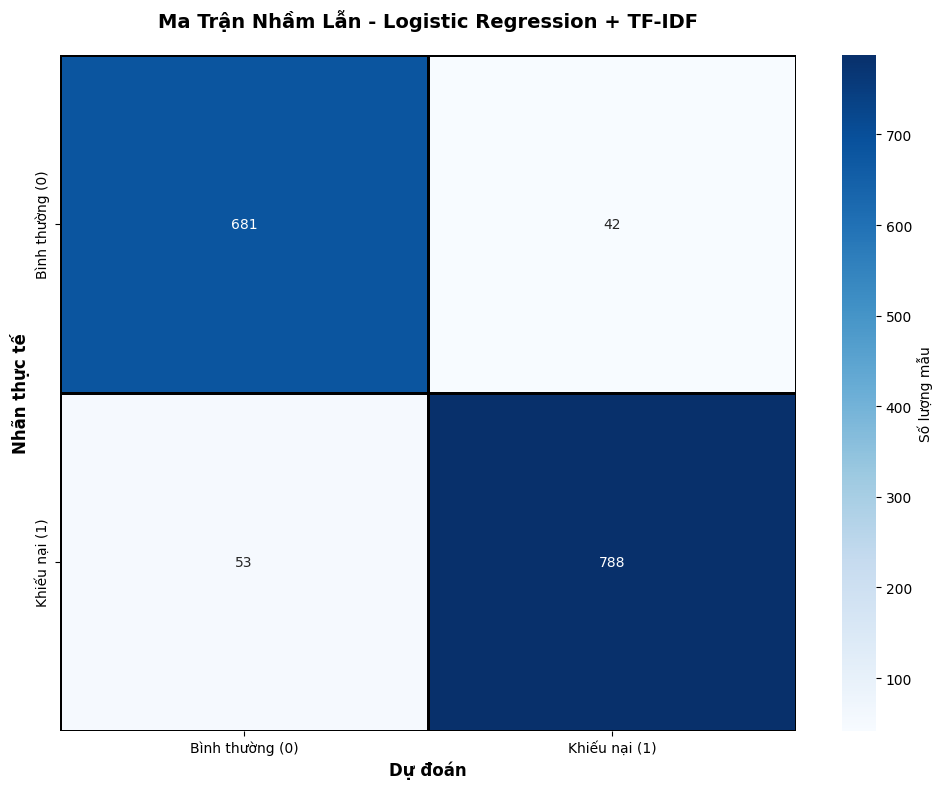

[OK] Biểu đồ Confusion Matrix đã được lưu!
[INFO] Các chỉ số:
  - True Negative (TN):  681 (Dự đoán đúng: không khiếu nại)
  - False Positive (FP): 42 (Dự đoán sai: khiếu nại)
  - False Negative (FN): 53 (Dự đoán sai: không khiếu nại)
  - True Positive (TP):  788 (Dự đoán đúng: khiếu nại)


In [9]:
# Vẽ biểu đồ Confusion Matrix
print("[INFO] Vẽ biểu đồ Confusion Matrix...")

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Tạo figure
plt.figure(figsize=(10, 8))

# Vẽ heatmap
sns.heatmap(
    cm,
    annot=True,                           # Hiển thị số trong ô
    fmt='d',                              # Định dạng số nguyên
    cmap='Blues',                         # Màu sắc
    xticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    yticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    cbar_kws={'label': 'Số lượng mẫu'},
    linewidths=2,
    linecolor='black'
)

plt.title('Ma Trận Nhầm Lẫn - Logistic Regression + TF-IDF', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Dự đoán', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn thực tế', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("[OK] Biểu đồ Confusion Matrix đã được lưu!")
print(f"[INFO] Các chỉ số:")
print(f"  - True Negative (TN):  {cm[0, 0]} (Dự đoán đúng: không khiếu nại)")
print(f"  - False Positive (FP): {cm[0, 1]} (Dự đoán sai: khiếu nại)")
print(f"  - False Negative (FN): {cm[1, 0]} (Dự đoán sai: không khiếu nại)")
print(f"  - True Positive (TP):  {cm[1, 1]} (Dự đoán đúng: khiếu nại)")